# Clasificación de Imagenes con Dígitos Manuscritos basado en Dataset MNIST

El presente Notebook está desarrollado acorde a la metodología y al estándar más ampliamente utilizado en proyectos de ciencia de datos y míneria de datos: **CRISP-DM**.

---

### CRISP-DM

**CRISP-DM** (Cross Industry Standard Process for Data Mining) es un framework cíclico e iterativo para proyectos de Machine Learning compuesto por 6 fases:

| Fase | Descripción |
|------|-------------|
| 1. Business Understanding | Entender el problema de negocio y traducirlo a un objetivo analítico |
| 2. Data Understanding | Explorar los datos disponibles, su estructura y calidad |
| 3. Data Preparation | Limpiar, transformar y preparar los datos para el modelo |
| 4. Modeling | Seleccionar, entrenar y ajustar el modelo |
| 5. Evaluation | Evaluar el modelo contra los objetivos del negocio |
| 6. Deployment | Exportar y poner el modelo en producción |

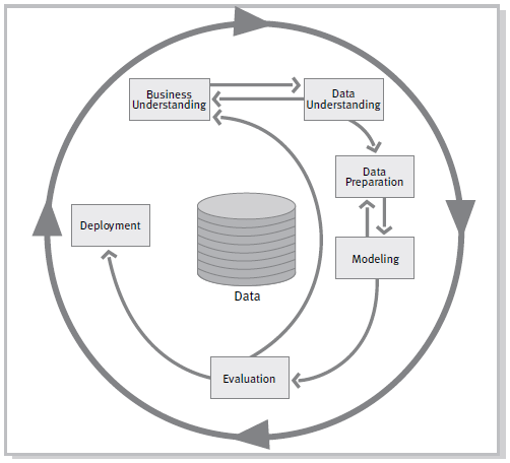

Imagen tomada de: **CRISP-DM: Fase de “Comprensión del negocio” (Business Understanding)** (11-2016) por Mikel Niño

---
## FASE 1 — Business Understanding (Entendimiento del Negocio)

### Contexto del problema
Se requiere un sistema capaz de **reconocer automáticamente dígitos manuscritos** (del 0 al 9) a partir de imágenes. Este tipo de problema tiene aplicaciones reales en:
- Lectura automática de formularios físicos
- Procesamiento de cheques bancarios
- Digitalización de documentos históricos

### Objetivo analítico
Construir un modelo de **clasificación multiclase** (10 clases: dígitos 0–9) que:
- Tenga alta precisión (objetivo: >98% accuracy en test)
- Sea generalizable (sin overfitting)
- Pueda ser consumido desde una API REST

### Criterio de éxito
- **Accuracy ≥ 98%** en el conjunto de prueba
- **F1-Score macro ≥ 0.98** (buen desempeño en todas las clases (números 0-9))
- Brecha train/test accuracy **< 1%** (sin overfitting significativo)
- Exportación del modelo funcional para consumo vía API

In [2]:
## Imports - Librerías necesarias para la creación del modelo
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Tensorflow and Keras - Librerías
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

## Measures - Métricas utilizadas
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

## Seed - Semilla base para reproducir un estándar de solución
SEED = 42
np.random.seed(SEED) ## Semilla de Numpy
tf.random.set_seed(SEED) ## Semilla de tensorflow

print(f'TensorFlow version: {tf.__version__}')

TensorFlow version: 2.16.1


---
## FASE 2 — Data Understanding (Entendimiento de los Datos)

### Dataset: MNIST
- **Origen:** Base de datos estándar de dígitos manuscritos (LeCun et al., 1998)
- **Tamaño:** 70,000 imágenes en escala de grises de 28×28 píxeles
- **Distribución:** 60,000 entrenamiento (train) / 10,000 prueba (test) (split estándar)
- **Clases:** 10 (dígitos del 0 al 9, balanceadas ~10% cada una)

### Carga de datos
Se utiliza la función `mnist.load_data()` de Keras para descargar el dataset automáticamente.

In [3]:
## Carga de Datos

(X_train_raw, y_train), (X_test_raw, y_test) = mnist.load_data()

print('=== Estructura del dataset ===')
print(f'X_train shape : {X_train_raw.shape}  -> {X_train_raw.shape[0]:,} imágenes de {X_train_raw.shape[1]}x{X_train_raw.shape[2]} px')
print(f'X_test shape  : {X_test_raw.shape}   -> {X_test_raw.shape[0]:,} imágenes de {X_test_raw.shape[1]}x{X_test_raw.shape[2]} px')
print(f'y_train shape : {y_train.shape}')
print(f'y_test shape  : {y_test.shape}')
print(f'\nRango de valores de píxeles: [{X_train_raw.min()}, {X_train_raw.max()}]')
print(f'Tipo de dato  : {X_train_raw.dtype}')

=== Estructura del dataset ===
X_train shape : (60000, 28, 28)  -> 60,000 imágenes de 28x28 px
X_test shape  : (10000, 28, 28)   -> 10,000 imágenes de 28x28 px
y_train shape : (60000,)
y_test shape  : (10000,)

Rango de valores de píxeles: [0, 255]
Tipo de dato  : uint8


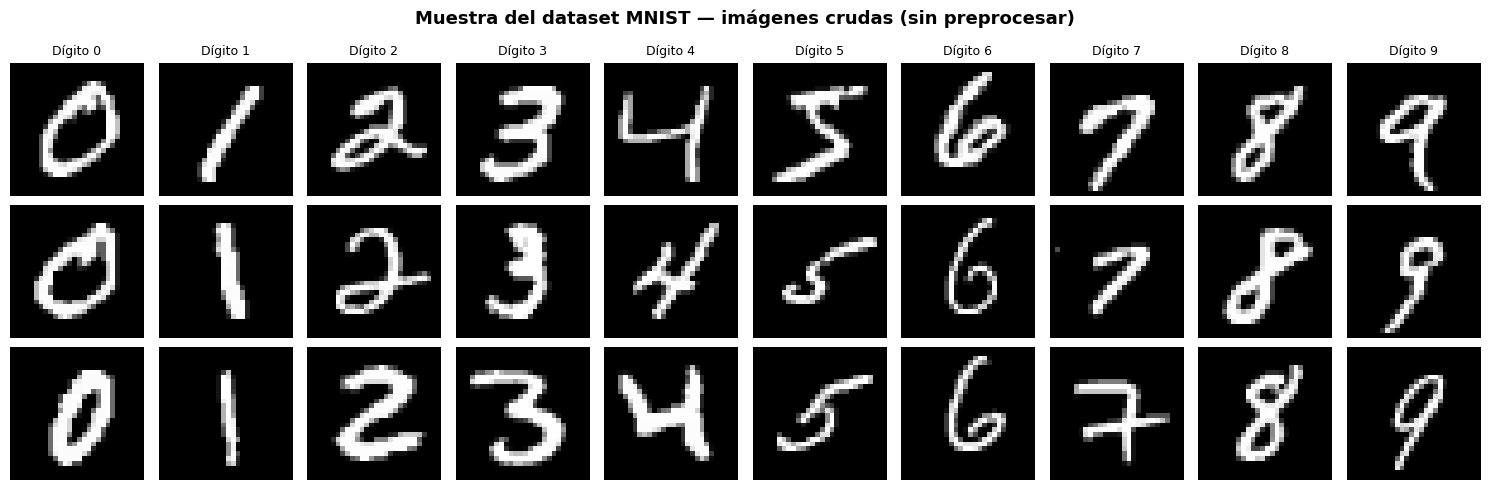

In [4]:
## Muestreo de los datos originales del Dataset

fig, axes = plt.subplots(3, 10, figsize=(15, 5))
fig.suptitle('Muestra del dataset MNIST — imágenes crudas (sin preprocesar)', fontsize=13, fontweight='bold')

for digit in range(10):
    idxs = np.where(y_train == digit)[0][:3]
    for row, idx in enumerate(idxs):
        axes[row, digit].imshow(X_train_raw[idx], cmap='gray')
        axes[row, digit].axis('off')
        if row == 0:
            axes[row, digit].set_title(f'Dígito {digit}', fontsize=9)

plt.tight_layout()
plt.show()

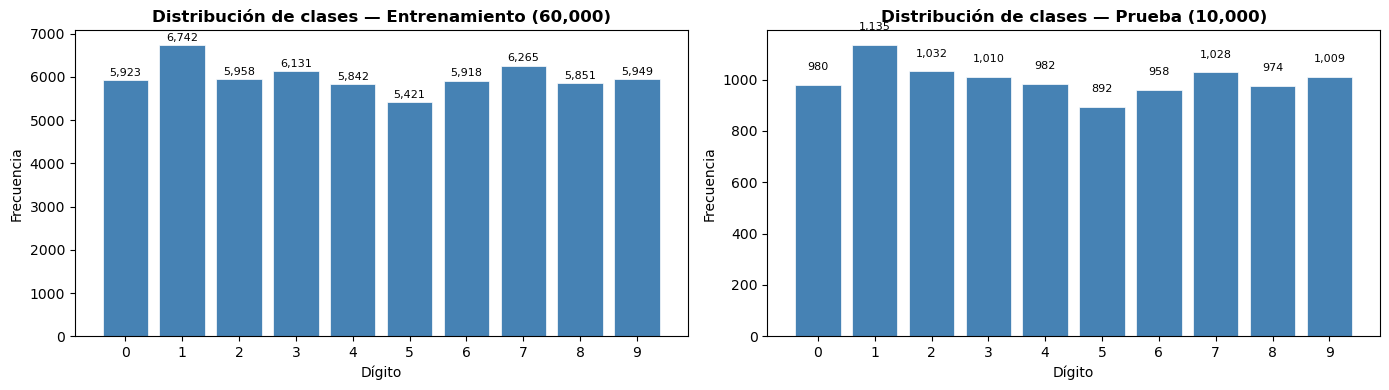

In [5]:
## Distribución de clases
## Visualización de la cantidad de imagenes por cada dígito (clase) en el dataset
## Se aprecia que aprox. cada dígito tiene un porcentaje de imagenes cercano al 10%

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (labels, title) in zip(axes, [(y_train, 'Entrenamiento (60,000)'), (y_test, 'Prueba (10,000)')]):
    unique, counts = np.unique(labels, return_counts=True)
    bars = ax.bar(unique, counts, color='steelblue', edgecolor='white', linewidth=0.5)
    ax.set_title(f'Distribución de clases — {title}', fontweight='bold')
    ax.set_xlabel('Dígito')
    ax.set_ylabel('Frecuencia')
    ax.set_xticks(unique)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{count:,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

---
## FASE 3 — Data Preparation (Preparación de los Datos)

### Transformaciones realizadas

| Transformación | Razón |
|----------------|-------|
| **Reshape a (N, 28, 28, 1)** | Las redes convolucionales (CNN) esperan tensores 4D: `(batch, alto, ancho, canales)`. Se agrega el canal de escala de grises (1) |
| **Normalización /255.0 → [0,1]** | Los valores de píxel originales están en [0, 255]. Dividir por 255 los lleva a [0, 1], lo que acelera la convergencia del gradiente descendente y evita que gradientes exploten |
| **One-hot encoding de etiquetas** | La función de pérdida `categorical_crossentropy` requiere etiquetas en formato one-hot. Ej: 3 → [0,0,0,1,0,0,0,0,0,0] |

MNIST es un dataset limpio, balanceado y con 60,000 muestras. Por los tipos de imágenes que maneja no es necesario realizar: rotaciones grandes, zoom, etc. Esto podría degradar el modelo ya que los dígitos manuscritos tienen orientaciones específicas. Se aplica sólo normalización.

In [6]:
## Preprocesamiento de los datos

# 1. Reshape: (N, 28, 28) → (N, 28, 28, 1)  para CNN
X_train = X_train_raw.reshape(-1, 28, 28, 1)
X_test  = X_test_raw.reshape(-1, 28, 28, 1)

# 2. Normalización: uint8 [0,255] → float32 [0.0, 1.0]
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

# 3. One-hot encoding de etiquetas
NUM_CLASSES = 10
y_train_ohe = to_categorical(y_train, NUM_CLASSES)
y_test_ohe  = to_categorical(y_test,  NUM_CLASSES)

print('=== Resultado del preprocesamiento ===')
print(f'X_train : {X_train.shape}  dtype={X_train.dtype}  rango=[{X_train.min():.1f}, {X_train.max():.1f}]')
print(f'X_test  : {X_test.shape}   dtype={X_test.dtype}  rango=[{X_test.min():.1f}, {X_test.max():.1f}]')
print(f'y_train_ohe : {y_train_ohe.shape}  (ejemplo: {y_train[0]} → {y_train_ohe[0].astype(int)})')

=== Resultado del preprocesamiento ===
X_train : (60000, 28, 28, 1)  dtype=float32  rango=[0.0, 1.0]
X_test  : (10000, 28, 28, 1)   dtype=float32  rango=[0.0, 1.0]
y_train_ohe : (60000, 10)  (ejemplo: 5 → [0 0 0 0 0 1 0 0 0 0])


---
## FASE 4 — Modeling (Modelado)

### Selección del modelo: CNN (Red Neuronal Convolucional)

**¿Por qué una CNN y no un modelo plano (MLP)?**
- Las CNN explotan la **estructura espacial** de las imágenes: los píxeles cercanos están relacionados
- Son **invariantes a traslaciones**: detectan un patrón (ej. un arco del dígito 8) sin importar su posición
- Logran mayor accuracy con menos parámetros que un MLP equivalente

### Arquitectura propuesta (Capas de la Red Neuronal)

```
Input (28×28×1)
  │
  ├─ Conv2D(32, 3×3) + ReLU  →  BatchNorm  →  MaxPool(2×2)
  │
  ├─ Conv2D(64, 3×3) + ReLU  →  BatchNorm  →  MaxPool(2×2)
  │
  ├─ Conv2D(128, 3×3) + ReLU →  BatchNorm
  │
  ├─ Flatten
  │
  ├─ Dense(256) + ReLU  →  Dropout(0.5)
  │
  └─ Dense(10) + Softmax
```

### Estrategias anti-overfitting
- **BatchNormalization:** estabiliza distribuciones de activación durante entrenamiento
- **Dropout(0.5):** elimina aleatoriamente neuronas para evitar co-adaptación
- **EarlyStopping:** detiene el entrenamiento cuando val_loss deja de mejorar (importante para reducir el tiempo de procesamiento)
- **ReduceLROnPlateau:** reduce learning rate cuando el modelo se estanca

In [7]:
## Construcción del modelo

def build_cnn(input_shape=(28, 28, 1), num_classes=10):
    model = models.Sequential([
        # --- Bloque convolucional 1 ---
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # --- Bloque convolucional 2 ---
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # --- Bloque clasificador ---
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ], name='MNIST_CNN')
    return model

model = build_cnn()
model.summary()

Model: "MNIST_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 28, 28, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 28, 28, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 28, 28, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 14, 14, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 14, 14, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 14, 14, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         803,072 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 872,426 (3.33 MB)

 Trainable params: 871,530 (3.32 MB)

 Non-trainable params: 896 (3.50 KB)

In [8]:
## Compilación y Calbacks del Modelo
## Se configuran los optimizadores, el stopper del modelado cuando no se obtiene una mejor métrica durante 5 epocs, entre otros

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cb_early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,               # 5 epocs sin mejora sustancial en la métrica "accuracy" detendrán el procesamiento
    restore_best_weights=True,
    verbose=1
)

cb_reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

cb_checkpoint = callbacks.ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

print(f'Parámetros totales del modelo : {model.count_params():,}')
print(f'Parámetros entrenables        : {sum(p.numpy().size for p in model.trainable_variables):,}')

Parámetros totales del modelo : 872,426
Parámetros entrenables        : 871,530


In [9]:
## Entrenamiento del Modelo

BATCH_SIZE = 128
EPOCHS     = 30  # EarlyStopping lo detendrá antes si no hay mejora en la métrica "accuracy"

history = model.fit(
    X_train, y_train_ohe,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.1,      # 10% de entrenamiento como validación
    callbacks=[cb_early_stop, cb_reduce_lr, cb_checkpoint],   # Se agregan los callbacks configurados en la celda anterior
    verbose=1
)

print(f'\nEntrenamiento finalizado en {len(history.history["loss"])} epocs.')

Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.8875 - loss: 0.3827
Epoch 1: val_accuracy improved from -inf to 0.90683, saving model to best_model.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 90ms/step - accuracy: 0.8876 - loss: 0.3822 - val_accuracy: 0.9068 - val_loss: 0.3318 - learning_rate: 0.0010
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9786 - loss: 0.0679
Epoch 2: val_accuracy improved from 0.90683 to 0.98350, saving model to best_model.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 38s 89ms/step - accuracy: 0.9786 - loss: 0.0679 - val_accuracy: 0.9835 - val_loss: 0.0558 - learning_rate: 0.0010
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9854 - loss: 0.0470
Epoch 3: val_accuracy improved from 0.98350 to 0.99033, saving model to best_model.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 38s 91ms/step - accuracy: 0.9854 - loss: 0.0470 - val_accuracy: 0.9903 - val_loss: 0.0361 - learning_rate: 0.0010
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 88m

---
## FASE 5 — Evaluation (Evaluación)

### Métricas seleccionadas

| Métrica | Descripción | Explicación |
|---------|-------------|---------------|
| **Accuracy** | % de predicciones correctas | Métrica base para clasificación balanceada |
| **Precision (macro)** | De las predicciones de clase C, cuántas son realmente C | Importante cuando los falsos positivos tienen costo (ej. confundir 7 con 1) |
| **Recall (macro)** | De los dígitos reales clase C, cuántos se detectaron | Importante cuando los falsos negativos tienen costo |
| **F1-Score (macro)** | Media armónica de Precision y Recall | Balanceo entre ambas métricas; robusto para evaluación multiclase (dígitos) |
| **Curvas Accuracy/Loss** | Evolución durante entrenamiento | Diagnostica overfitting/underfitting visualmente |
| **Matriz de confusión** | Qué dígitos se confunden entre sí | Identifica errores sistemáticos del modelo |

### ¿A qué hace referencia Macro?

Dada la necesidad de trabajar con 10 clases (dígitos) balanceadas, macro average pesa igual cada clase, siendo equivalente a micro pero más informativo para detectar clases con bajo rendimiento individual (números que no se detecten bien en las imágenes).

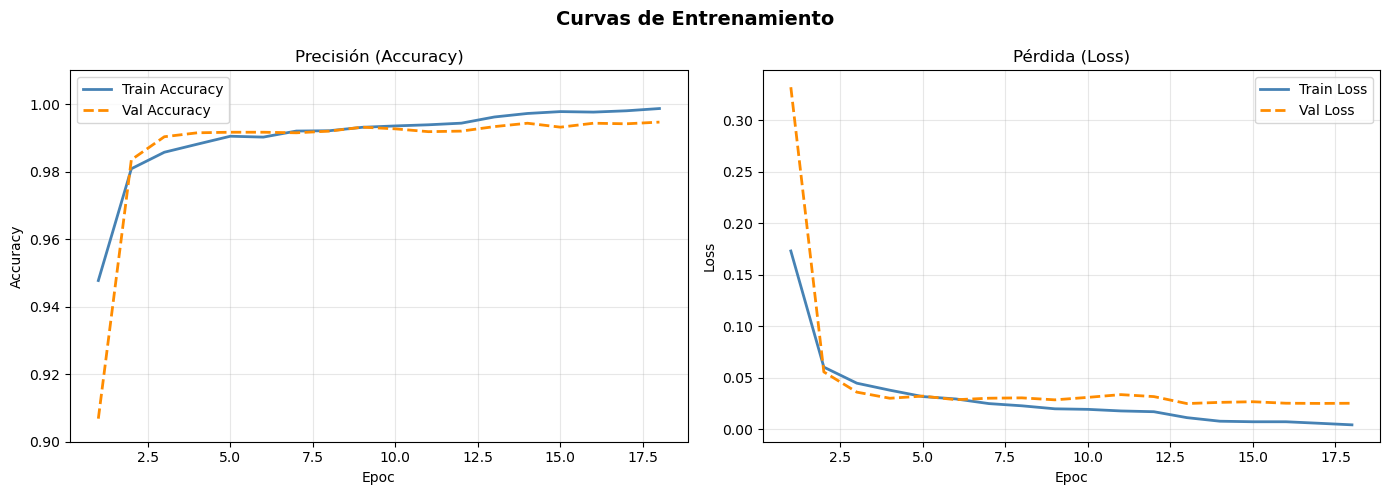

Curva Amarilla de la gráfica -> Valores de Accuracy/Loss obtenidos con el set de datos de Validación (en cada Epoc)
Curva Azul de la gráfica -> Valores de Accuracy/Loss obtenidos con el set de datos de Entrenamiento (en cada Epoc)

Train Accuracy final : 0.9987
Val Accuracy final   : 0.9947
Brecha train/val     : 0.0040 (Sin overfitting significativo)


In [10]:
## Curvas de Entrenamiento — Accuracy y Loss
## Curva Amarilla de la gráfica -> Valores de Accuracy/Loss obtenidos con el set de datos de Validación (en cada Epoc)
## Curva Azul de la gráfica -> Valores de Accuracy/Loss obtenidos con el set de datos de Entrenamiento (en cada Epoc)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Curvas de Entrenamiento', fontsize=14, fontweight='bold')

epochs_range = range(1, len(history.history['accuracy']) + 1)

# Accuracy
axes[0].plot(epochs_range, history.history['accuracy'],     label='Train Accuracy', color='steelblue', linewidth=2)
axes[0].plot(epochs_range, history.history['val_accuracy'], label='Val Accuracy',   color='darkorange', linewidth=2, linestyle='--')
axes[0].set_title('Precisión (Accuracy)')
axes[0].set_xlabel('Epoc')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_ylim([0.9, 1.01])

# Loss
axes[1].plot(epochs_range, history.history['loss'],     label='Train Loss', color='steelblue', linewidth=2)
axes[1].plot(epochs_range, history.history['val_loss'], label='Val Loss',   color='darkorange', linewidth=2, linestyle='--')
axes[1].set_title('Pérdida (Loss)')
axes[1].set_xlabel('Epoc')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Diagnóstico de overfitting
final_train_acc = history.history['accuracy'][-1]
final_val_acc   = history.history['val_accuracy'][-1]
gap = abs(final_train_acc - final_val_acc)
print(f'Curva Amarilla de la gráfica -> Valores de Accuracy/Loss obtenidos con el set de datos de Validación (en cada Epoc)')
print(f'Curva Azul de la gráfica -> Valores de Accuracy/Loss obtenidos con el set de datos de Entrenamiento (en cada Epoc)')
print(f'\nTrain Accuracy final : {final_train_acc:.4f}')
print(f'Val Accuracy final   : {final_val_acc:.4f}')
print(f'Brecha train/val     : {gap:.4f} ({"Sin overfitting significativo" if gap < 0.01 else "Revisar overfitting del modelo"})')

In [11]:
## Evaluación del modelo

test_loss, test_accuracy = model.evaluate(X_test, y_test_ohe, verbose=0)

# Predicciones
y_pred_proba = model.predict(X_test, verbose=0)
y_pred       = np.argmax(y_pred_proba, axis=1)

# Métricas detalladas
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall    = recall_score(y_test, y_pred, average='macro')
f1        = f1_score(y_test, y_pred, average='macro')

print('=' * 50)
print('      MÉTRICAS EN CONJUNTO DE PRUEBA')
print('=' * 50)
print(f'  Accuracy        : {accuracy:.4f}  ({accuracy*100:.2f}%)')
print(f'  Precision macro : {precision:.4f}')
print(f'  Recall macro    : {recall:.4f}')
print(f'  F1-Score macro  : {f1:.4f}')
print(f'  Test Loss       : {test_loss:.4f}')
print('=' * 50)
print(f'  Objetivo accuracy ≥ 98%: {"El modelo cumple con el objetivo propuesto" if accuracy >= 0.98 else "El modelo no cumple con el objetivo"}')

      MÉTRICAS EN CONJUNTO DE PRUEBA
  Accuracy        : 0.9948  (99.48%)
  Precision macro : 0.9949
  Recall macro    : 0.9947
  F1-Score macro  : 0.9948
  Test Loss       : 0.0169
  Objetivo accuracy ≥ 98%: El modelo cumple con el objetivo propuesto


In [12]:
## Reporte de clasificación por Dígito

print('Reporte de clasificación por dígito:')
print(classification_report(y_test, y_pred, target_names=[f'Dígito {i}' for i in range(10)]))

Reporte de clasificación por dígito:
              precision    recall  f1-score   support

    Dígito 0       1.00      1.00      1.00       980
    Dígito 1       0.99      1.00      0.99      1135
    Dígito 2       1.00      1.00      1.00      1032
    Dígito 3       1.00      1.00      1.00      1010
    Dígito 4       0.99      1.00      1.00       982
    Dígito 5       0.99      0.99      0.99       892
    Dígito 6       1.00      0.99      0.99       958
    Dígito 7       1.00      0.99      0.99      1028
    Dígito 8       1.00      0.99      1.00       974
    Dígito 9       1.00      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



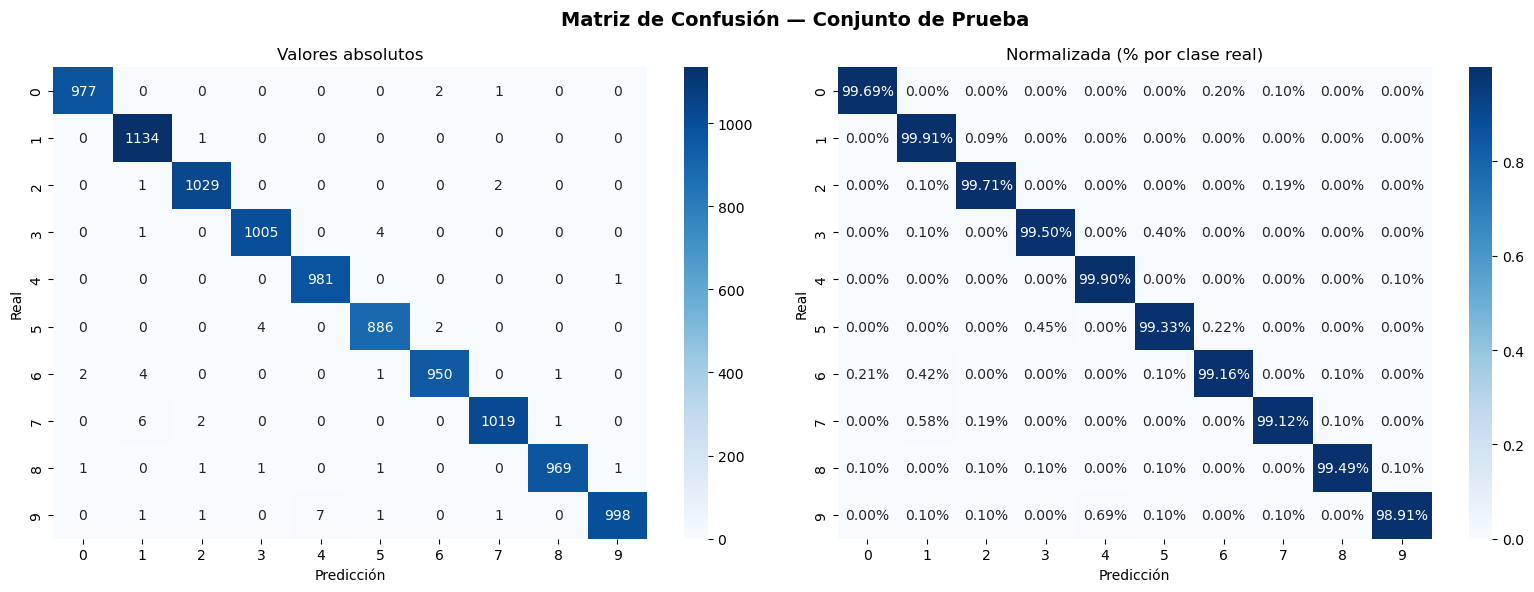


Errores por clase (Top 3 de dígitos con más confusiones para el modelo):
  Dígito 9: 11 errores
  Dígito 7: 9 errores
  Dígito 6: 8 errores


In [13]:
## Matriz de confusión

cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Matriz de Confusión — Conjunto de Prueba', fontsize=14, fontweight='bold')

# Valores absolutos
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=range(10), yticklabels=range(10))
axes[0].set_title('Valores absolutos')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')

# Valores normalizados (%)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=range(10), yticklabels=range(10))
axes[1].set_title('Normalizada (% por clase real)')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

# Clases con más errores
errors_per_class = cm.sum(axis=1) - np.diag(cm)
print('\nErrores por clase (Top 3 de dígitos con más confusiones para el modelo):')
for idx in np.argsort(errors_per_class)[::-1][:3]:
    print(f'  Dígito {idx}: {errors_per_class[idx]} errores')

---
## Validación Visual — 32 Imágenes del Dataset de Prueba

Se escogen 32 imágenes del dataset de prueba para **validar cualitativamente (visualmente)** que el modelo reconoce correctamente los patrones visuales de los dígitos, no sólo que tiene alto accuracy.

- **Verde:** predicción correcta (etiqueta real = predicha)
- **Rojo:** predicción incorrecta (error del modelo)

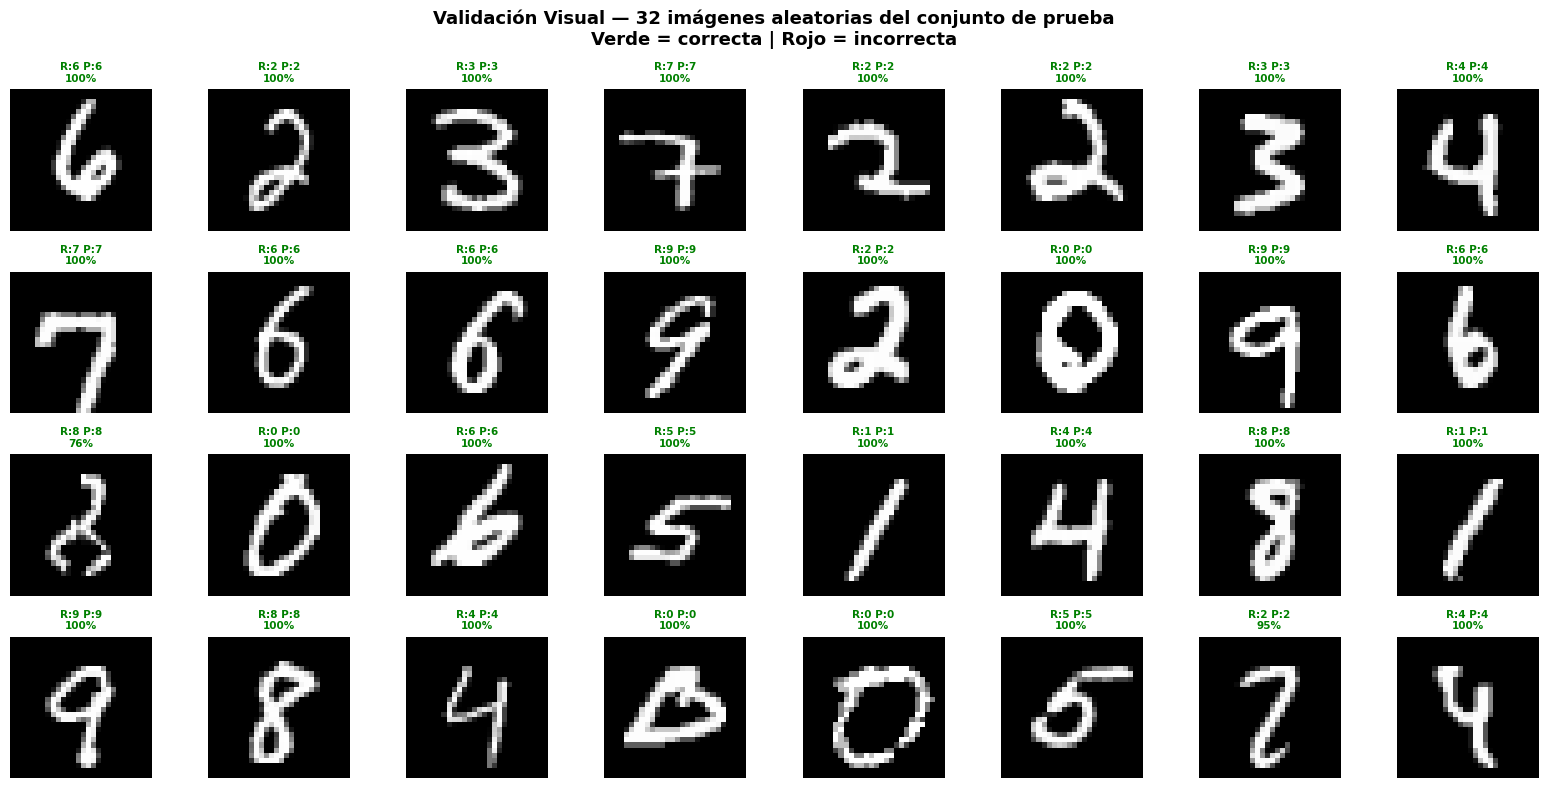

Resultados en la muestra de 32 imágenes:
  Correctas   : 32/32 (100%)
  Incorrectas : 0/32


In [14]:
## Validación Visual del Modelo (Modelo en acción frente a 32 imágenes aleatorias)

N_SHOW = 32
np.random.seed(SEED) # Configuración de semlilla para el random de la librería Numpy
sample_idx = np.random.choice(len(X_test), N_SHOW, replace=False) # Se escogen 32 imágenes de manera aleatoria del set de prueba

n_cols = 8
n_rows = N_SHOW // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 8))
fig.suptitle(
    'Validación Visual — 32 imágenes aleatorias del conjunto de prueba\n'
    'Verde = correcta | Rojo = incorrecta',
    fontsize=13, fontweight='bold'
)

correct = 0
for i, idx in enumerate(sample_idx):
    row, col = divmod(i, n_cols)
    ax = axes[row, col]

    imagen  = X_test_raw[idx]
    real    = y_test[idx]
    pred    = y_pred[idx]
    conf    = y_pred_proba[idx][pred]
    is_ok   = (real == pred)
    correct += is_ok

    ax.imshow(imagen, cmap='gray')
    ax.axis('off')

    color = 'green' if is_ok else 'red'
    label = f'R:{real} P:{pred}\n{conf:.0%}'
    ax.set_title(label, fontsize=7.5, color=color, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Resultados en la muestra de {N_SHOW} imágenes:')
print(f'  Correctas   : {correct}/{N_SHOW} ({correct/N_SHOW:.0%})')
print(f'  Incorrectas : {N_SHOW - correct}/{N_SHOW}')

Total de errores en test set: 52 de 10,000 (0.52%)


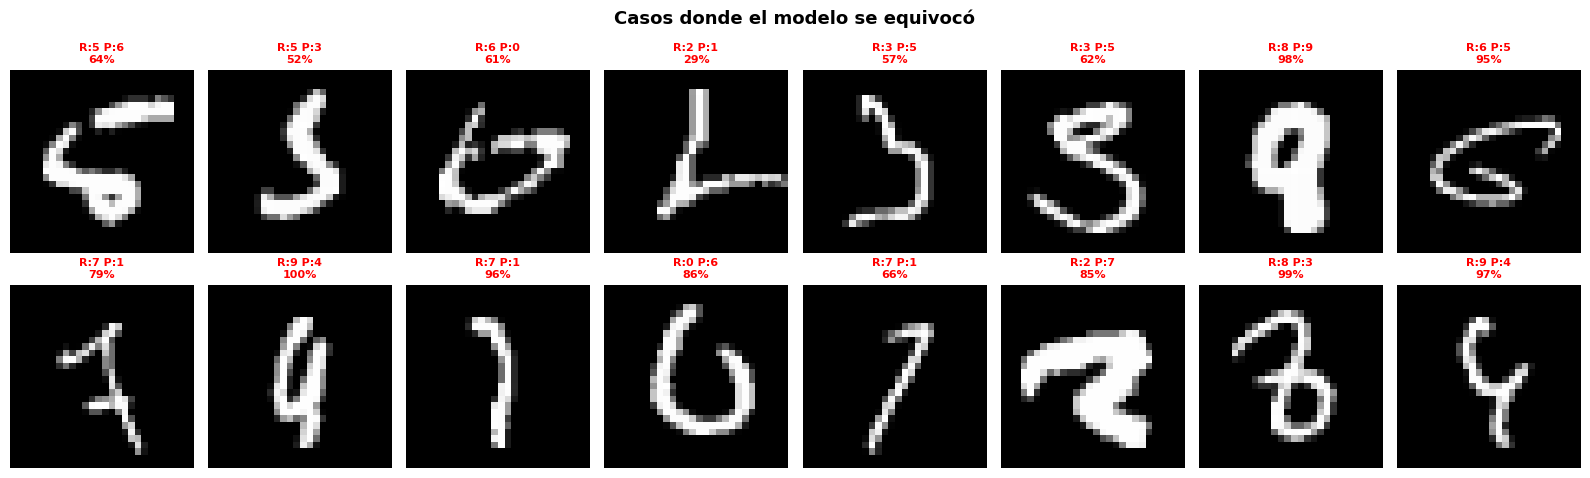

In [15]:
## ¿Cómo funciona el modelo en comparación del dataset completo de mnist?
## De las 10.000 imágenes del Dataset original, ¿Cuantas imágenes el modelo equivocó en su predicción?

error_idx = np.where(y_pred != y_test)[0]
print(f'Total de errores en test set: {len(error_idx)} de {len(y_test):,} ({len(error_idx)/len(y_test):.2%})')

if len(error_idx) > 0:
    n_show_errors = min(16, len(error_idx))
    sample_errors = error_idx[:n_show_errors]

    fig, axes = plt.subplots(2, 8, figsize=(16, 5))
    fig.suptitle('Casos donde el modelo se equivocó', fontsize=13, fontweight='bold')

    for i, idx in enumerate(sample_errors):
        ax = axes[i // 8, i % 8]
        ax.imshow(X_test_raw[idx], cmap='gray')
        ax.axis('off')
        conf = y_pred_proba[idx][y_pred[idx]]
        ax.set_title(f'R:{y_test[idx]} P:{y_pred[idx]}\n{conf:.0%}', fontsize=8, color='red', fontweight='bold')

    plt.tight_layout()
    plt.show()

---
## FASE 6 — Deployment (Despliegue - Exportar modelo)

### Exportación del modelo

Se exporta el modelo en formato **`.keras`** (formato nativo de TensorFlow 2.x), uno de los más recomendados porque:
- Guarda arquitectura + pesos + configuración del optimizador en un solo archivo
- Es compatible con la función `keras.models.load_model()`, utilizada para cargar el modelo en Python
- No depende de versiones específicas de Python para ser utilizado

El modelo exportado será cargado directamente por la API REST para hacer inferencia a imágenes en base 64.

In [16]:
## Exportar modelo

import os

MODEL_PATH = 'api/model/mnist_cnn.keras'
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)

model.save(MODEL_PATH)
print(f'Modelo guardado en: {MODEL_PATH}')

# Verificar que el archivo existe y su tamaño
size_mb = os.path.getsize(MODEL_PATH) / (1024 * 1024)
print(f'Tamaño del archivo: {size_mb:.2f} MB')

# Verificación de carga
print('\nVerificando carga del modelo exportado...')
model_loaded = keras.models.load_model(MODEL_PATH)
pred_verify  = np.argmax(model_loaded.predict(X_test[:5], verbose=0), axis=1)
real_verify  = y_test[:5]
print(f'Predicciones verificación : {pred_verify}')
print(f'Etiquetas reales          : {real_verify}')
print(f'Modelo cargado y funcional: {np.all(pred_verify == real_verify)}')

Modelo guardado en: api/model/mnist_cnn.keras
Tamaño del archivo: 10.05 MB

Verificando carga del modelo exportado...
Predicciones verificación : [7 2 1 0 4]
Etiquetas reales          : [7 2 1 0 4]
Modelo cargado y funcional: True
